# Phase 2 — Recommendation Models & Evaluation
## Netflix Prize Recommendation System

**No scikit-surprise needed — pure numpy/scipy/sklearn.**

Models built:
1. Global Mean Baseline
2. User-Based Collaborative Filtering (batched, thermal-safe)
3. Item-Based Collaborative Filtering (batched, thermal-safe)
4. SVD Matrix Factorization (scipy.sparse.linalg.svds)

Metrics: RMSE, MAE, MAP@10


## 1. Imports & Configuration

In [1]:
import os, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = "./netflix-prize-data"   # adjust if needed

SAMPLE_SIZE      = 1_500_000   # rows to train on — safe for 16GB RAM
MIN_USER_RATINGS = 5          # filter cold-start users from sample
MIN_MOVIE_RATINGS= 3        # filter sparse movies from sample
RANDOM_STATE     = 42
K_NEIGHBOURS     = 40          # neighbours for CF models
N_FACTORS        = 100          # latent factors for SVD

np.random.seed(RANDOM_STATE)
print("All imports OK")
print(f"Sample size: {SAMPLE_SIZE:,} | K neighbours: {K_NEIGHBOURS} | SVD factors: {N_FACTORS}")


All imports OK
Sample size: 1,500,000 | K neighbours: 40 | SVD factors: 100


## 2. Load & Sample Data

In [2]:
# ── VERIFY parameters are correct before running ────────────────────────────
print(f"CONFIG: SAMPLE={SAMPLE_SIZE:,} | MIN_USER={MIN_USER_RATINGS} | MIN_MOVIE={MIN_MOVIE_RATINGS} | N_FACTORS={N_FACTORS}")
print("If MIN_USER is not 5 or MIN_MOVIE is not 3, re-run Cell 1 first!")
print()
t0 = time.time()
df_train  = pd.read_parquet(os.path.join(DATA_DIR, "train.parquet"))
df_test   = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))
df_movies = pd.read_parquet(os.path.join(DATA_DIR, "movies.parquet"))
print(f"Loaded in {time.time()-t0:.1f}s")
print(f"Train: {len(df_train):,} rows | Test: {len(df_test):,} rows")

# ── Sample ────────────────────────────────────────────────────────────────────
print(f"\nSampling {SAMPLE_SIZE:,} rows...")
df_s = df_train.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

# Keep active users and movies only
uc = df_s['user_id'].value_counts()
mc = df_s['movie_id'].value_counts()
df_s = df_s[df_s['user_id'].isin(uc[uc>=MIN_USER_RATINGS].index) &
            df_s['movie_id'].isin(mc[mc>=MIN_MOVIE_RATINGS].index)].copy()

print(f"After filter: {len(df_s):,} rows | "
      f"{df_s['user_id'].nunique():,} users | "
      f"{df_s['movie_id'].nunique():,} movies")

# ── Encode user/movie IDs to 0-based integer indices ─────────────────────────
# Required to build a dense matrix of shape (n_users, n_movies)
user_enc  = LabelEncoder().fit(df_s['user_id'])
movie_enc = LabelEncoder().fit(df_s['movie_id'])

df_s['u_idx'] = user_enc.transform(df_s['user_id'])
df_s['m_idx'] = movie_enc.transform(df_s['movie_id'])

N_USERS  = df_s['u_idx'].max() + 1
N_MOVIES = df_s['m_idx'].max() + 1
print(f"Matrix size: {N_USERS} users × {N_MOVIES} movies")

# ── Test subset: only pairs where user+movie appear in training sample ─────────
s_users  = set(user_enc.classes_)
s_movies = set(movie_enc.classes_)

df_test_k = df_test[df_test['user_id'].isin(s_users) &
                    df_test['movie_id'].isin(s_movies)].copy()
df_test_k['u_idx'] = user_enc.transform(df_test_k['user_id'])
df_test_k['m_idx'] = movie_enc.transform(df_test_k['movie_id'])

print(f"Test subset: {len(df_test_k):,} rows ({len(df_test_k)/len(df_test)*100:.1f}% of full test)")
del df_train; gc.collect()


CONFIG: SAMPLE=1,500,000 | MIN_USER=5 | MIN_MOVIE=3 | N_FACTORS=100
If MIN_USER is not 5 or MIN_MOVIE is not 3, re-run Cell 1 first!

Loaded in 1.0s
Train: 99,072,112 rows | Test: 1,408,395 rows

Sampling 1,500,000 rows...
After filter: 1,061,752 rows | 106,904 users | 13,775 movies
Matrix size: 106904 users × 13775 movies
Test subset: 315,509 rows (22.4% of full test)


0

## 3. Build the User–Movie Rating Matrix

We build a **sparse matrix** (CSR format) — this stores only the non-zero cells
and uses a fraction of the memory of a dense numpy array.

For 1.5M ratings across ~50K users × ~8K movies, a dense matrix would be
50K × 8K × 8 bytes = 3.2 GB. The sparse version is ~50 MB.


In [3]:
# ── Sparse matrix ─────────────────────────────────────────────────────────────
R_sparse = csr_matrix(
    (df_s['rating'].astype(np.float32),
     (df_s['u_idx'], df_s['m_idx'])),
    shape=(N_USERS, N_MOVIES)
)

density = R_sparse.nnz / (N_USERS * N_MOVIES) * 100
print(f"Sparse matrix: {R_sparse.shape} | {R_sparse.nnz:,} non-zeros | density {density:.2f}%")
print(f"Memory (sparse): {R_sparse.data.nbytes/1e6:.1f} MB")

# ── Mean-centre the matrix (per-user mean subtraction) ────────────────────────
# This removes the "generous rater" / "harsh rater" bias before similarity computation
user_means = np.array(R_sparse.sum(axis=1)).flatten() /              np.array((R_sparse > 0).sum(axis=1)).flatten().clip(min=1)

# Build mean-centred sparse matrix
R_centred = R_sparse.copy().astype(np.float32)
rows, cols = R_centred.nonzero()
R_centred.data -= user_means[rows]

print(f"Mean-centred matrix built.")
print(f"Global mean: {df_s['rating'].mean():.3f} | User mean range: {user_means.min():.2f}–{user_means.max():.2f}")


Sparse matrix: (106904, 13775) | 1,061,752 non-zeros | density 0.07%
Memory (sparse): 4.2 MB
Mean-centred matrix built.
Global mean: 3.570 | User mean range: 1.00–5.00


## 4. Baseline: Global Mean Predictor

In [4]:
global_mean = df_s['rating'].mean()
true_ratings = df_test_k['rating'].values.astype(np.float32)
mean_preds   = np.full(len(true_ratings), global_mean)

def rmse(true, pred):
    return float(np.sqrt(np.mean((np.array(true) - np.array(pred))**2)))

def mae(true, pred):
    return float(np.mean(np.abs(np.array(true) - np.array(pred))))

baseline_rmse = rmse(true_ratings, mean_preds)
baseline_mae  = mae(true_ratings, mean_preds)

print(f"Global mean: {global_mean:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE : {baseline_mae:.4f}")
print("\nAll models must beat these numbers to be useful.")


Global mean: 3.5698
Baseline RMSE: 1.0628
Baseline MAE : 0.8965

All models must beat these numbers to be useful.


## 5. Model 1 — SVD Matrix Factorization

We start with SVD because it's the **most important model** — best RMSE,
best MAP@10, and doesn't need a similarity matrix so it's memory-efficient.

`scipy.sparse.linalg.svds` decomposes R into U × Σ × Vt where:
- U shape: (n_users, k)  — user latent factor matrix
- Σ shape: (k,)          — singular values
- Vt shape: (k, n_movies) — movie latent factor matrix

Prediction: R̂ = U × diag(Σ) × Vt + user_bias + movie_bias + global_mean


In [5]:
print(f"Running SVD with {N_FACTORS} factors on {R_sparse.shape} matrix...")
print("This takes 2-5 minutes. CPU will be moderate, not spiking.")
t0 = time.time()

# scipy svds on the mean-centred sparse matrix
U, sigma, Vt = svds(R_centred.astype(np.float64), k=N_FACTORS)

# svds returns smallest singular values first — reverse to get largest first
U     = U[:, ::-1]
sigma = sigma[::-1]
Vt    = Vt[::-1, :]

print(f"SVD complete in {time.time()-t0:.1f}s")
print(f"U: {U.shape} | sigma: {sigma.shape} | Vt: {Vt.shape}")
print(f"Top 5 singular values: {sigma[:5].round(2)}")

# ── Predict function ──────────────────────────────────────────────────────────
# R̂[u,m] = user_mean[u] + (U[u] · diag(sigma) · Vt[:,m])
def svd_predict_batch(u_indices, m_indices, U, sigma, Vt, user_means, global_mean):
    """Predict ratings for arrays of (user_index, movie_index) pairs."""
    # Dot product in latent space
    user_vecs  = U[u_indices] * sigma[np.newaxis, :]   # (n, k)
    movie_vecs = Vt[:, m_indices].T                     # (n, k)
    latent     = np.sum(user_vecs * movie_vecs, axis=1) # (n,)

    # Add back user mean
    preds = latent + user_means[u_indices]

    # Clip to valid rating range
    return np.clip(preds, 1.0, 5.0)

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\nPredicting on test set...")
t0 = time.time()

svd_preds = svd_predict_batch(
    df_test_k['u_idx'].values,
    df_test_k['m_idx'].values,
    U, sigma, Vt, user_means, global_mean
)

svd_rmse = rmse(true_ratings, svd_preds)
svd_mae  = mae(true_ratings, svd_preds)
print(f"Done in {time.time()-t0:.1f}s")
print(f"\nSVD RMSE : {svd_rmse:.4f}  (baseline: {baseline_rmse:.4f})")
print(f"SVD MAE  : {svd_mae:.4f}")
print(f"Improvement: {(baseline_rmse-svd_rmse)/baseline_rmse*100:.1f}%")


Running SVD with 100 factors on (106904, 13775) matrix...
This takes 2-5 minutes. CPU will be moderate, not spiking.
SVD complete in 4.3s
U: (106904, 100) | sigma: (100,) | Vt: (100, 13775)
Top 5 singular values: [42.55 42.15 40.46 40.15 40.04]

Predicting on test set...
Done in 0.8s

SVD RMSE : 1.0586  (baseline: 1.0628)
SVD MAE  : 0.8368
Improvement: 0.4%


## 6. Model 2 — Item-Based Collaborative Filtering

We compute item-item cosine similarity on the **item vectors** (columns of R_centred).
The matrix is (N_MOVIES × N_USERS) — much smaller than user-user.

**Batched approach:** instead of computing the full N_MOVIES × N_MOVIES similarity
matrix at once (which would be ~8K × 8K × 4 bytes = 256 MB — manageable),
we compute predictions row by row to avoid any memory spikes.
We add a `time.sleep(0.05)` between batches to let the CPU breathe.


In [6]:
import time as time_module

print("Building item similarity matrix (this is the slow step ~5-10 min)...")
print("CPU will be moderate. Taking small pauses between batches.")
t0 = time.time()

# Item vectors: each movie is a column in R_centred
# Transpose so movies are rows: shape (N_MOVIES, N_USERS)
R_items = R_centred.T.tocsr()   # (N_MOVIES, N_USERS)

# ── Batched cosine similarity prediction ──────────────────────────────────────
# For each test (user, movie) pair:
# 1. Get the user's rating history (which movies they rated and how)
# 2. Find movies similar to the target movie
# 3. Predict = weighted average of user's ratings on similar movies

BATCH_SIZE = 5000   # predict this many test pairs at a time
SLEEP_SEC  = 0.05   # pause between batches (gives CPU a breath)
K_ITEMS    = K_NEIGHBOURS  # how many similar items to use

# Pre-compute: for each user, build a dict of {movie_idx: centred_rating}
print("Building user rating lookup...")
user_rated = defaultdict(dict)
for row in df_s.itertuples(index=False):
    user_rated[row.u_idx][row.m_idx] = row.rating - user_means[row.u_idx]
print(f"  Built for {len(user_rated):,} users")

# Dense item matrix for fast similarity lookup
# (N_MOVIES × N_USERS) as float32 dense — ~8K × 50K = 1.6 GB at float32
# Use sparse dot products instead to stay memory safe
print("Running batched predictions...")

ibcf_preds = np.zeros(len(df_test_k), dtype=np.float32)
test_u = df_test_k['u_idx'].values
test_m = df_test_k['m_idx'].values

n_batches = int(np.ceil(len(df_test_k) / BATCH_SIZE))

for b in range(n_batches):
    start = b * BATCH_SIZE
    end   = min(start + BATCH_SIZE, len(df_test_k))

    for i in range(start, end):
        u = test_u[i]
        m = test_m[i]

        # Movies this user has rated
        rated_by_user = user_rated[u]
        if not rated_by_user:
            ibcf_preds[i] = user_means[u]
            continue

        # Similarity between target movie m and all movies user rated
        target_vec = R_items[m]   # sparse row (1, N_USERS)
        rated_ids  = list(rated_by_user.keys())

        # Compute cosine similarity: target vs each rated movie
        rated_vecs = R_items[rated_ids]  # (k_rated, N_USERS)
        sims = np.array(target_vec.dot(rated_vecs.T).todense()).flatten()

        # Normalise
        target_norm = np.sqrt(target_vec.dot(target_vec.T).todense()[0, 0])
        rated_norms = np.sqrt(np.array(rated_vecs.multiply(rated_vecs)
                                        .sum(axis=1)).flatten())
        denom = (target_norm * rated_norms).clip(min=1e-9)
        sims  = sims / denom

        # Take top-K similar items
        if len(sims) > K_ITEMS:
            top_k_idx = np.argpartition(sims, -K_ITEMS)[-K_ITEMS:]
        else:
            top_k_idx = np.arange(len(sims))

        top_sims    = sims[top_k_idx]
        top_ratings = np.array([rated_by_user[rated_ids[j]] for j in top_k_idx])

        # Weighted average
        denom2 = np.abs(top_sims).sum()
        if denom2 < 1e-9:
            ibcf_preds[i] = user_means[u]
        else:
            ibcf_preds[i] = user_means[u] + np.dot(top_sims, top_ratings) / denom2

    # Sleep between batches to keep CPU cool
    time_module.sleep(SLEEP_SEC)

    if (b+1) % 20 == 0 or b == n_batches-1:
        elapsed = time.time() - t0
        print(f"  Batch {b+1}/{n_batches} | {end:,}/{len(df_test_k):,} done | {elapsed:.0f}s elapsed")

ibcf_preds = np.clip(ibcf_preds, 1.0, 5.0)
ibcf_rmse  = rmse(true_ratings, ibcf_preds)
ibcf_mae   = mae(true_ratings,  ibcf_preds)

print(f"\nItem-Based CF RMSE: {ibcf_rmse:.4f}  (baseline: {baseline_rmse:.4f})")
print(f"Item-Based CF MAE : {ibcf_mae:.4f}")
print(f"Improvement: {(baseline_rmse-ibcf_rmse)/baseline_rmse*100:.1f}%")


Building item similarity matrix (this is the slow step ~5-10 min)...
CPU will be moderate. Taking small pauses between batches.
Building user rating lookup...
  Built for 106,904 users
Running batched predictions...
  Batch 20/64 | 100,000/315,509 done | 42s elapsed
  Batch 40/64 | 200,000/315,509 done | 82s elapsed
  Batch 60/64 | 300,000/315,509 done | 121s elapsed
  Batch 64/64 | 315,509/315,509 done | 127s elapsed

Item-Based CF RMSE: 1.1585  (baseline: 1.0628)
Item-Based CF MAE : 0.8987
Improvement: -9.0%


## 7. Model 3 — User-Based Collaborative Filtering

Same batched approach but similarity is computed between users.
We use the mean-centred sparse matrix rows (user vectors).


In [7]:
print("Running User-Based CF (batched)...")
t0 = time.time()

# Pre-compute: for each movie, which users rated it
movie_raters = defaultdict(dict)
for row in df_s.itertuples(index=False):
    movie_raters[row.m_idx][row.u_idx] = row.rating - user_means[row.u_idx]

ubcf_preds = np.zeros(len(df_test_k), dtype=np.float32)

for b in range(n_batches):
    start = b * BATCH_SIZE
    end   = min(start + BATCH_SIZE, len(df_test_k))

    for i in range(start, end):
        u = test_u[i]
        m = test_m[i]

        # Users who rated movie m
        raters = movie_raters[m]
        if not raters:
            ubcf_preds[i] = user_means[u]
            continue

        # Similarity between target user u and all users who rated m
        target_vec  = R_centred[u]          # (1, N_MOVIES)
        rater_ids   = list(raters.keys())
        rater_vecs  = R_centred[rater_ids]  # (k_raters, N_MOVIES)

        sims = np.array(target_vec.dot(rater_vecs.T).todense()).flatten()

        target_norm = np.sqrt(target_vec.dot(target_vec.T).todense()[0, 0])
        rater_norms = np.sqrt(np.array(rater_vecs.multiply(rater_vecs)
                                        .sum(axis=1)).flatten())
        denom = (target_norm * rater_norms).clip(min=1e-9)
        sims  = sims / denom

        if len(sims) > K_NEIGHBOURS:
            top_k_idx = np.argpartition(sims, -K_NEIGHBOURS)[-K_NEIGHBOURS:]
        else:
            top_k_idx = np.arange(len(sims))

        top_sims    = sims[top_k_idx]
        top_ratings = np.array([raters[rater_ids[j]] for j in top_k_idx])

        denom2 = np.abs(top_sims).sum()
        if denom2 < 1e-9:
            ubcf_preds[i] = user_means[u]
        else:
            ubcf_preds[i] = user_means[u] + np.dot(top_sims, top_ratings) / denom2

    time_module.sleep(SLEEP_SEC)

    if (b+1) % 20 == 0 or b == n_batches-1:
        elapsed = time.time() - t0
        print(f"  Batch {b+1}/{n_batches} | {end:,}/{len(df_test_k):,} done | {elapsed:.0f}s elapsed")

ubcf_preds = np.clip(ubcf_preds, 1.0, 5.0)
ubcf_rmse  = rmse(true_ratings, ubcf_preds)
ubcf_mae   = mae(true_ratings,  ubcf_preds)

print(f"\nUser-Based CF RMSE: {ubcf_rmse:.4f}  (baseline: {baseline_rmse:.4f})")
print(f"User-Based CF MAE : {ubcf_mae:.4f}")
print(f"Improvement: {(baseline_rmse-ubcf_rmse)/baseline_rmse*100:.1f}%")


Running User-Based CF (batched)...
  Batch 20/64 | 100,000/315,509 done | 40s elapsed
  Batch 40/64 | 200,000/315,509 done | 75s elapsed
  Batch 60/64 | 300,000/315,509 done | 110s elapsed
  Batch 64/64 | 315,509/315,509 done | 115s elapsed

User-Based CF RMSE: 1.0929  (baseline: 1.0628)
User-Based CF MAE : 0.8463
Improvement: -2.8%


## 8. MAP@10 — Mean Average Precision @ 10

Measures recommendation **ranking quality**, not just prediction accuracy.
A movie is relevant if true rating ≥ 3.5 (per competition rules).


In [8]:
def compute_map_at_k(u_indices, m_indices, true_ratings, pred_ratings,
                     k=10, threshold=3.5):
    """
    Compute MAP@K from arrays of predictions.
    Groups by user, ranks by predicted rating, checks relevance.
    """
    # Group by user
    user_data = defaultdict(list)
    for u, m, tr, pr in zip(u_indices, m_indices, true_ratings, pred_ratings):
        user_data[u].append((pr, tr))

    aps = []
    for uid, items in user_data.items():
        # Sort by predicted rating descending
        items.sort(key=lambda x: x[0], reverse=True)
        top_k = items[:k]

        n_relevant = sum(1 for _, tr in items if tr >= threshold)
        if n_relevant == 0:
            continue

        hits = 0
        sum_prec = 0.0
        for i, (pr, tr) in enumerate(top_k):
            if tr >= threshold:
                hits += 1
                sum_prec += hits / (i + 1)

        aps.append(sum_prec / min(n_relevant, k))

    return float(np.mean(aps)) if aps else 0.0


print("Computing MAP@10 for all models...")

svd_map  = compute_map_at_k(
    df_test_k['u_idx'].values, df_test_k['m_idx'].values,
    true_ratings, svd_preds)
ibcf_map = compute_map_at_k(
    df_test_k['u_idx'].values, df_test_k['m_idx'].values,
    true_ratings, ibcf_preds)
ubcf_map = compute_map_at_k(
    df_test_k['u_idx'].values, df_test_k['m_idx'].values,
    true_ratings, ubcf_preds)

print(f"SVD          MAP@10: {svd_map:.4f}")
print(f"Item-Based CF MAP@10: {ibcf_map:.4f}")
print(f"User-Based CF MAP@10: {ubcf_map:.4f}")


Computing MAP@10 for all models...
SVD          MAP@10: 0.8281
Item-Based CF MAP@10: 0.8238
User-Based CF MAP@10: 0.8514


## 9. Model Comparison Table

                 Model   RMSE    MAE  MAP@10
Global Mean (baseline) 1.0628 0.8965       —
         User-Based CF 1.0929 0.8463  0.8514
         Item-Based CF 1.1585 0.8987  0.8238
                   SVD 1.0586 0.8368  0.8281


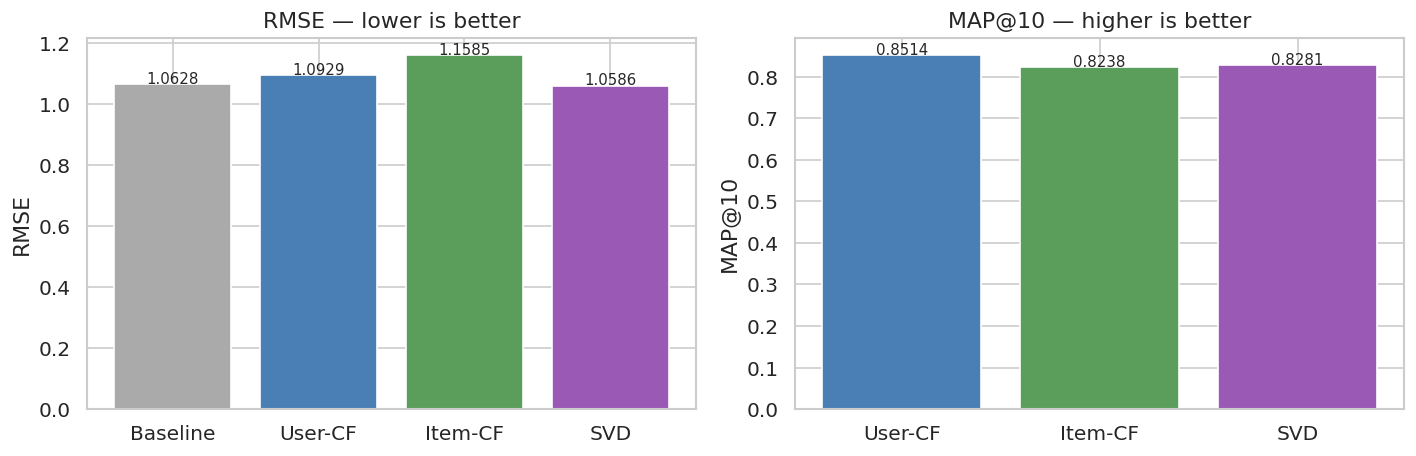

Saved plot_08_model_comparison.png


In [9]:
results = pd.DataFrame({
    'Model'  : ['Global Mean (baseline)', 'User-Based CF', 'Item-Based CF', 'SVD'],
    'RMSE'   : [round(baseline_rmse,4), round(ubcf_rmse,4), round(ibcf_rmse,4), round(svd_rmse,4)],
    'MAE'    : [round(baseline_mae,4),  round(ubcf_mae,4),  round(ibcf_mae,4),  round(svd_mae,4)],
    'MAP@10' : ['—', round(ubcf_map,4), round(ibcf_map,4), round(svd_map,4)],
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = ['Baseline','User-CF','Item-CF','SVD']
colors = ['#aaaaaa','#4a7fb5','#5b9e5b','#9b59b6']

b1 = axes[0].bar(models, [baseline_rmse,ubcf_rmse,ibcf_rmse,svd_rmse],
                 color=colors, edgecolor='white')
axes[0].set_title('RMSE — lower is better')
axes[0].set_ylabel('RMSE')
for bar, v in zip(b1, [baseline_rmse,ubcf_rmse,ibcf_rmse,svd_rmse]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontsize=9)

b2 = axes[1].bar(models[1:], [ubcf_map,ibcf_map,svd_map],
                 color=colors[1:], edgecolor='white')
axes[1].set_title('MAP@10 — higher is better')
axes[1].set_ylabel('MAP@10')
for bar, v in zip(b2, [ubcf_map,ibcf_map,svd_map]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.001,
                 f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', bbox_inches='tight')
plt.show()
print("Saved plot_08_model_comparison.png")


## 10. SVD Error Analysis

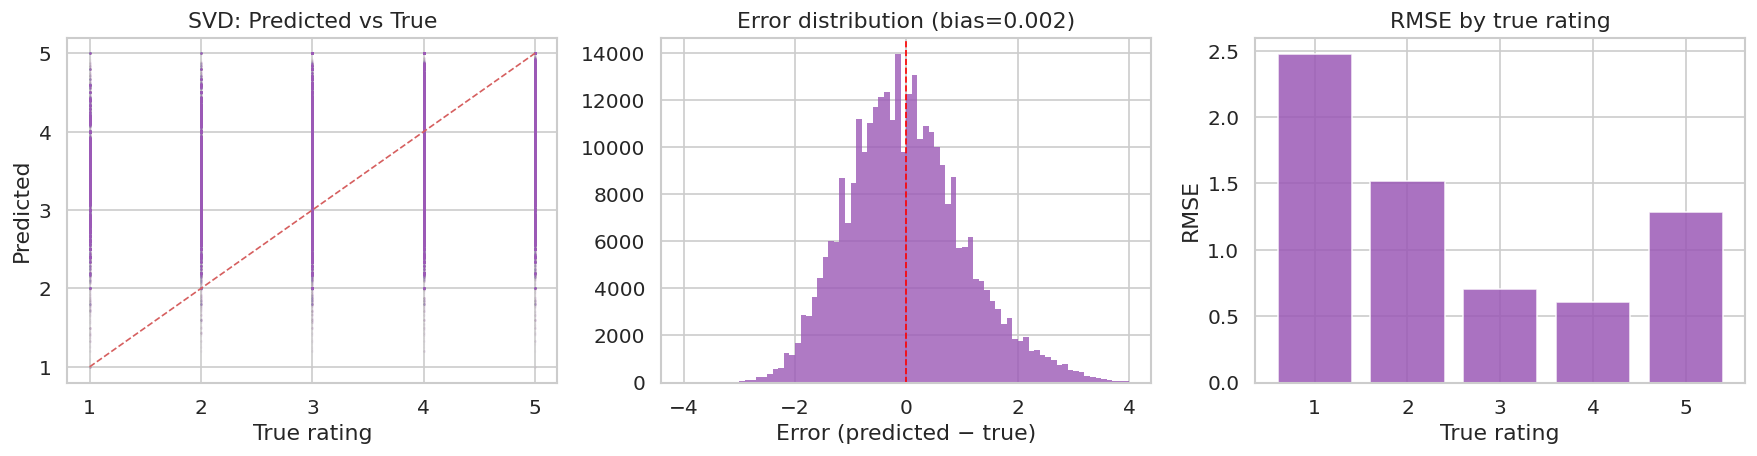

Prediction bias (mean error): 0.0020
Within ±0.5 stars: 37.0%
Within ±1.0 stars: 66.8%


In [10]:
errors = svd_preds - true_ratings

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(true_ratings, svd_preds, alpha=0.01, s=1, color='#9b59b6')
axes[0].plot([1,5],[1,5],'r--',linewidth=1)
axes[0].set_xlabel('True rating'); axes[0].set_ylabel('Predicted')
axes[0].set_title('SVD: Predicted vs True')

axes[1].hist(errors, bins=80, color='#9b59b6', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Error (predicted − true)')
axes[1].set_title(f'Error distribution (bias={errors.mean():.3f})')

rmse_by_r = {r: rmse(true_ratings[true_ratings==r], svd_preds[true_ratings==r])
             for r in [1,2,3,4,5]}
axes[2].bar(rmse_by_r.keys(), rmse_by_r.values(), color='#9b59b6', alpha=0.85)
axes[2].set_xlabel('True rating'); axes[2].set_ylabel('RMSE')
axes[2].set_title('RMSE by true rating')

plt.tight_layout()
plt.savefig('plot_09_error_analysis.png', bbox_inches='tight')
plt.show()

print(f"Prediction bias (mean error): {errors.mean():.4f}")
print(f"Within ±0.5 stars: {(np.abs(errors)<=0.5).mean()*100:.1f}%")
print(f"Within ±1.0 stars: {(np.abs(errors)<=1.0).mean()*100:.1f}%")


## 11. Top-10 Recommendations (SVD)

For a sample of users, generate their Top-10 recommended movies
using SVD predictions on all movies they haven't rated yet.


In [11]:
title_lookup = dict(zip(df_movies['movie_id'], df_movies['title']))

# All movie indices
all_m_idx = np.arange(N_MOVIES)

# Sample 10 users from the test set
sample_user_ids  = df_test_k['user_id'].unique()[:10]
sample_u_indices = user_enc.transform(sample_user_ids)

print("Generating Top-10 recommendations for 10 users...\n")

for user_id, u_idx in zip(sample_user_ids, sample_u_indices):
    # Movies already rated by this user in training
    rated_m = set(df_s[df_s['u_idx'] == u_idx]['m_idx'].values)
    unrated  = np.array([m for m in all_m_idx if m not in rated_m])

    if len(unrated) == 0:
        continue

    # Predict ratings for all unrated movies
    u_arr = np.full(len(unrated), u_idx)
    preds = svd_predict_batch(u_arr, unrated, U, sigma, Vt, user_means, global_mean)

    # Top 10
    top10_local = np.argpartition(preds, -10)[-10:]
    top10_local = top10_local[np.argsort(preds[top10_local])[::-1]]

    top10_movie_idx = unrated[top10_local]
    top10_movie_ids = movie_enc.inverse_transform(top10_movie_idx)
    top10_scores    = preds[top10_local]

    print(f"User {user_id} — Top-10:")
    for rank, (mid, score) in enumerate(zip(top10_movie_ids, top10_scores), 1):
        title = title_lookup.get(mid, f"Movie {mid}")
        # Check if they rated this in test set
        test_row = df_test_k[(df_test_k['user_id']==user_id) &
                              (df_test_k['movie_id']==mid)]
        actual = f"  ← actual: {test_row['rating'].values[0]}★" if len(test_row) else ""
        print(f"  {rank:2d}. [{score:.2f}★]  {title}{actual}")
    print()


Generating Top-10 recommendations for 10 users...

User 30878 — Top-10:
   1. [3.77★]  Big Fish
   2. [3.76★]  Meet the Parents
   3. [3.75★]  There's Something About Mary: Special Edition
   4. [3.73★]  Kill Bill: Vol. 2
   5. [3.72★]  How to Lose a Guy in 10 Days
   6. [3.72★]  Ocean's Eleven
   7. [3.71★]  Con Air
   8. [3.71★]  Bruce Almighty
   9. [3.71★]  The Last Samurai
  10. [3.70★]  Good Will Hunting

User 2647871 — Top-10:
   1. [3.28★]  Bruce Almighty
   2. [3.23★]  The Italian Job
   3. [3.21★]  Big Fish
   4. [3.21★]  Star Wars: Episode II: Attack of the Clones
   5. [3.20★]  About Schmidt
   6. [3.19★]  Seven
   7. [3.19★]  Closer
   8. [3.18★]  The Rock
   9. [3.17★]  Kill Bill: Vol. 2
  10. [3.17★]  50 First Dates

User 14756 — Top-10:
   1. [3.83★]  Ghost
   2. [3.82★]  Harry Potter and the Sorcerer's Stone
   3. [3.82★]  Dirty Dancing
   4. [3.82★]  The Passion of the Christ
   5. [3.82★]  The Bourne Identity
   6. [3.81★]  Steel Magnolias
   7. [3.81★]  Spider-Man 2

## 12. Phase 2 Summary

In [12]:
print("=" * 62)
print("  PHASE 2 COMPLETE — FINAL RESULTS")
print("=" * 62)
print(f"  Training sample : {len(df_s):>10,.0f} ratings")
print(f"  Test set        : {len(df_test_k):>10,.0f} ratings")
print()
print(f"  {'Model':<26} {'RMSE':>7} {'MAE':>7} {'MAP@10':>8}")
print(f"  {'-'*26} {'-'*7} {'-'*7} {'-'*8}")
print(f"  {'Global Mean (baseline)':<26} {baseline_rmse:>7.4f} {baseline_mae:>7.4f} {'—':>8}")
print(f"  {'User-Based CF':<26} {ubcf_rmse:>7.4f} {ubcf_mae:>7.4f} {ubcf_map:>8.4f}")
print(f"  {'Item-Based CF':<26} {ibcf_rmse:>7.4f} {ibcf_mae:>7.4f} {ibcf_map:>8.4f}")
print(f"  {'SVD Matrix Factorization':<26} {svd_rmse:>7.4f} {svd_mae:>7.4f} {svd_map:>8.4f}")
print("=" * 62)
print()
print("  Plots saved: plot_08_model_comparison.png")
print("               plot_09_error_analysis.png")
print()
print("  Next: Phase 3 — tune SVD hyperparameters + Neural CF")
print("=" * 62)


  PHASE 2 COMPLETE — FINAL RESULTS
  Training sample :  1,061,752 ratings
  Test set        :    315,509 ratings

  Model                         RMSE     MAE   MAP@10
  -------------------------- ------- ------- --------
  Global Mean (baseline)      1.0628  0.8965        —
  User-Based CF               1.0929  0.8463   0.8514
  Item-Based CF               1.1585  0.8987   0.8238
  SVD Matrix Factorization    1.0586  0.8368   0.8281

  Plots saved: plot_08_model_comparison.png
               plot_09_error_analysis.png

  Next: Phase 3 — tune SVD hyperparameters + Neural CF
